# High and low Jet $p_t$ EFT Coefficients

The goal of this notebook is to compare the frequency of coefficients being the largest in events with total Jet $p_t$ above and below 500 GeV

### Importing packages

In [3]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np

### Names for each pair

In [4]:
# Names from json file:
names_json = ["SM","cQu8","ctu8","cQu1","ctd8","cQlMi","cpQ3","ctlTi","ctG","ctZ","ctW","ctli","ctb8","cbW","cQl3i","cQq13",
              "cptb","ctp","ctei","cpQM","ctlSi", "cQq83","cQq81","ctq1","ctu1","cQei","cQb8","cpt","ctq8","cQd1","cQq11",
              "cQd8","ctd1"]

# All 561 combinations of coefficients (i.e SM,SM; SM,cQu8; cQu8,cQu8; SM,ctu8; cQu8,ctu8; ...)
name_combinations = []
for i in range(len(names_json)):
    for a in range(i+1):
        name_combinations.append([names_json[i],names_json[a]])

### Open file and branches

In [5]:
# Open file
file = uproot.open("sample_root_files/output_570.root")

In [6]:
# Open Events tree
events_tree = file['Events']

In [7]:
# Making array of EFT Coefficients
eft_coeff = events_tree['EFTfitCoefficients'].array()

In [8]:
# Making function that adds weights to the histograms below
def weights(data):
    return [1 / len(data)] * len(data)

In [9]:
# Making arrays of Jet pt and EFT Coefficients
jet_pt = events_tree['Jet_pt'].array()

## Jet code:

### Adding the jet $p_t$ from each jet in each event

In [10]:
sum_of_jet_pt_in_each_event = []

for i in range(len(jet_pt)):
    sum_of_jet_pt_in_each_event.append(sum(jet_pt[i]))

sum_of_jet_pt_in_each_event = np.array(sum_of_jet_pt_in_each_event)

### Applying cut of 500 GeV, finding the largest coefficient in that event, and appending to corresponding list

In [11]:
jet_pt_above_500 = sum_of_jet_pt_in_each_event > 500
eft_coeff_above_500 = []
eft_coeff_below_500 = []

for i,n in enumerate(jet_pt_above_500):                                       
    if n == False:
        eft_coeff_below_500.append(np.argmax(np.abs(eft_coeff[i])))           # np.argmax finds the index of the largest entry.
    else:
        eft_coeff_above_500.append(np.argmax(np.abs(eft_coeff[i])))

### Applying same treatment, but ignoring SM, SM pair
SM is not of interest, so it just acts as noise

In [12]:
jet_pt_above_500 = sum_of_jet_pt_in_each_event > 500
eft_coeff_above_500_filtering_out_SM = []
eft_coeff_below_500_filtering_out_SM = []

for i,n in enumerate(jet_pt_above_500):                                       
    if n == False:
        eft_coeff_below_500_filtering_out_SM.append(np.argmax(np.abs(eft_coeff[i][1:])) + 1)
        # +1 since the new list gets shifted by ignoring the first coefficient
    else:
        eft_coeff_above_500_filtering_out_SM.append(np.argmax(np.abs(eft_coeff[i][1:])) + 1)

### _Results of Jets with total $p_t$ above 500 Gev with and without SM, SM pair_

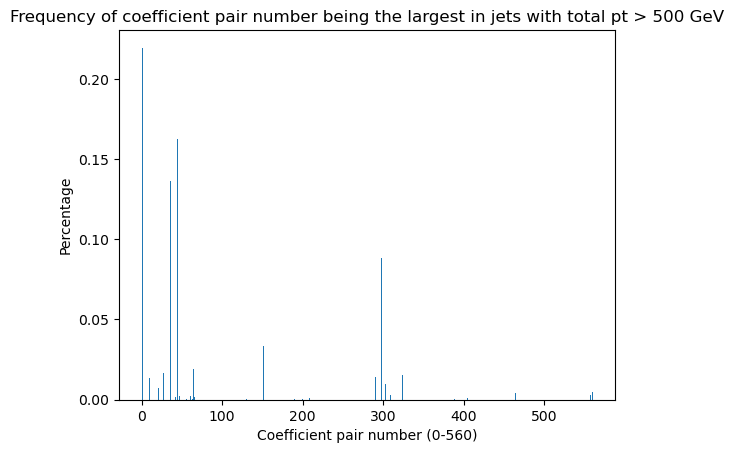

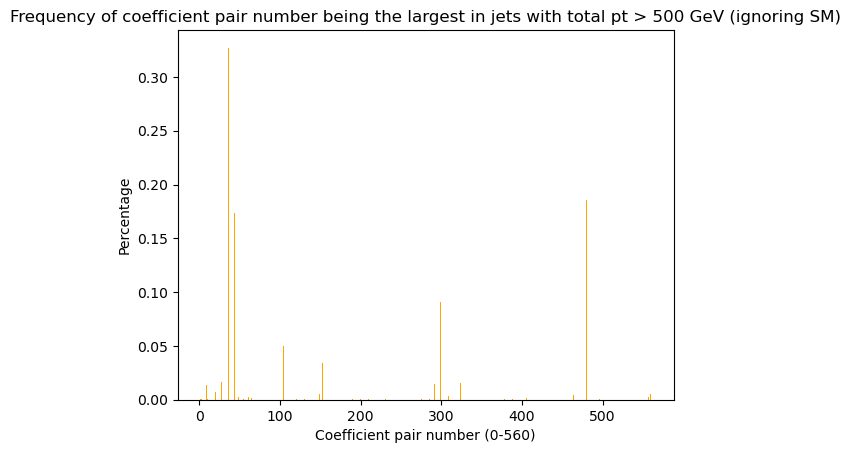

In [13]:
fig1 = plt.figure()
plt.hist(eft_coeff_above_500, bins = 500, weights = weights(eft_coeff_above_500))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Frequency of coefficient pair number being the largest in jets with total pt > 500 GeV')

fig2 = plt.figure()
plt.hist(eft_coeff_above_500_filtering_out_SM, bins = 500, weights = weights(eft_coeff_above_500_filtering_out_SM), color = 'orange')
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Frequency of coefficient pair number being the largest in jets with total pt > 500 GeV (ignoring SM)')

plt.show()

### _Results of Jets with total $p_t$ below 500 Gev with and without SM, SM pair_

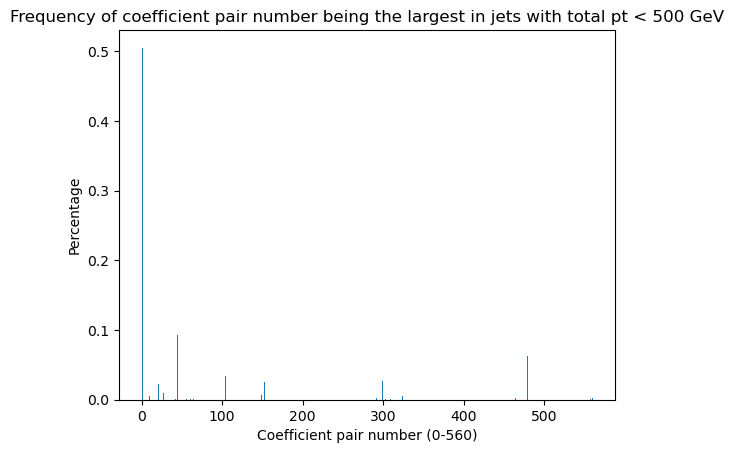

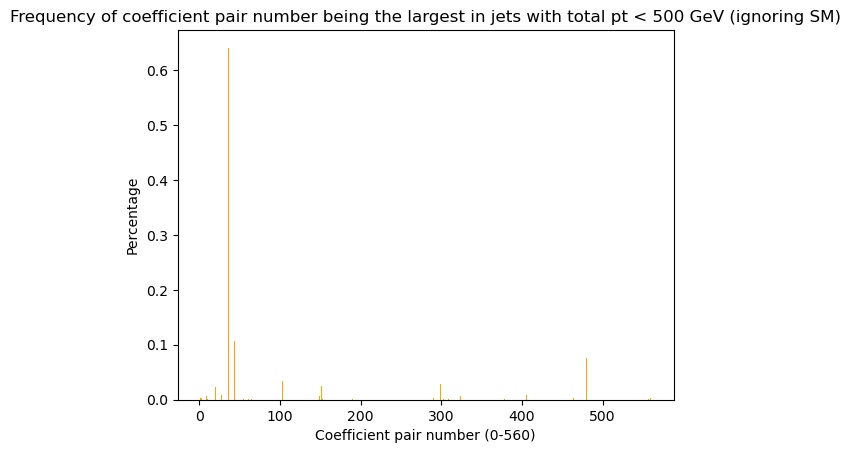

In [17]:
fig3 = plt.figure()
plt.hist(eft_coeff_below_500, bins=499, weights = weights(eft_coeff_below_500))
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Frequency of coefficient pair number being the largest in jets with total pt < 500 GeV')

fig4 = plt.figure()
plt.hist(eft_coeff_below_500_filtering_out_SM, bins = 499, weights = weights(eft_coeff_below_500_filtering_out_SM), color='orange')
plt.xlabel('Coefficient pair number (0-560)')
plt.ylabel('Percentage')
plt.title('Frequency of coefficient pair number being the largest in jets with total pt < 500 GeV (ignoring SM)')

plt.show()

### Printing the values -- hard to read from histogram alone

In [71]:
def interesting_coeff(data):
    percent_and_index = []
    for i in range(561):
        coeff_percentage = data.count(i) / len(data)
        if coeff_percentage >= 0.01:
            percent_and_index.append([round(coeff_percentage*100), i])
    
           
    percent_and_index = np.array(percent_and_index)
    indices = np.argsort(percent_and_index[:,0])                # This tells me the order of the rows
    percent_and_index_ordered = percent_and_index[indices][::-1] # This sorts the rows based on the indices and [::-1] makes it go in descending order
    
    for i in range(len(percent_and_index_ordered)):
        a = print(f'The pair {name_combinations[percent_and_index_ordered[i,1]]} with index {percent_and_index_ordered[i,1]} has {percent_and_index_ordered[i,0]}%')

    return a

In [29]:
# High pt, including SM
interesting_coeff(eft_coeff_above_500,'high')

["The pair ['SM', 'SM'] has index 0 and has a percentage 22% in high pt",
 "The pair ['cQu1', 'cQu1'] has index 9 and has a percentage 1% in high pt",
 "The pair ['cpQ3', 'cpQ3'] has index 27 and has a percentage 2% in high pt",
 "The pair ['ctG', 'SM'] has index 36 and has a percentage 14% in high pt",
 "The pair ['ctG', 'ctG'] has index 44 and has a percentage 16% in high pt",
 "The pair ['ctW', 'ctZ'] has index 64 and has a percentage 2% in high pt",
 "The pair ['cbW', 'cbW'] has index 104 and has a percentage 5% in high pt",
 "The pair ['cptb', 'cptb'] has index 152 and has a percentage 3% in high pt",
 "The pair ['ctq1', 'cQq13'] has index 291 and has a percentage 1% in high pt",
 "The pair ['ctq1', 'ctq1'] has index 299 and has a percentage 9% in high pt",
 "The pair ['ctu1', 'ctu1'] has index 324 and has a percentage 2% in high pt",
 "The pair ['cQq11', 'cQq13'] has index 480 and has a percentage 18% in high pt"]

In [245]:
# High pt, ignoring SM
interesting_coeff(eft_coeff_above_500_filtering_out_SM,'high')

The pair ['ctG', 'SM'] has index 36 and has a percentage 33% in high pt
The pair ['ctG', 'ctG'] has index 44 and has a percentage 17% in high pt
The pair ['ctq1', 'ctq1'] has index 299 and has a percentage 9% in high pt
The pair ['cQq11', 'cQq13'] has index 480 and has a percentage 19% in high pt


In [246]:
# Low pt, including SM
interesting_coeff(eft_coeff_below_500,'low')

The pair ['SM', 'SM'] has index 0 and has a percentage 50% in low pt
The pair ['ctG', 'SM'] has index 36 and has a percentage 19% in low pt
The pair ['ctG', 'ctG'] has index 44 and has a percentage 9% in low pt
The pair ['cQq11', 'cQq13'] has index 480 and has a percentage 6% in low pt


In [247]:
# Low pt, ignoring SM
interesting_coeff(eft_coeff_below_500_filtering_out_SM,'low')

The pair ['ctG', 'SM'] has index 36 and has a percentage 64% in low pt
The pair ['ctG', 'ctG'] has index 44 and has a percentage 11% in low pt
The pair ['cQq11', 'cQq13'] has index 480 and has a percentage 8% in low pt


### Finding how many times a pair number appears in a specific list

In [261]:
pair_number = 299
number_of_coefficient = 0
list_to_look_into = eft_coeff_below_500_filtering_out_SM
name_of_list = 'Jets below total 500 GeV'

for i in list_to_look_into:
    if i == pair_number:
       number_of_coefficient += 1 
print(f'The pair #{pair_number} appears {number_of_coefficient} times in EFT {name_of_list}' )

The pair #299 appears 662 times in EFT Jets below total 500 GeV


In [262]:
number_of_coefficient / len(eft_coeff_below_500_filtering_out_SM)

0.0293569844789357